# Check ML non linear implementation

In [54]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
df = pd.read_csv('../Data/gold/covid_multivariate_w_2.csv')
df.head()

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated
0,2020-03-23,Chile,1558,10261,5.828571,5.242857,10.619048,28.350649,37.952381,3.773810,19331414,30,8,9,32,19.456667,69.844286,0.0
1,2020-03-30,Chile,2420,24909,5.978571,6.516667,13.771429,38.922078,50.726190,4.035714,19331414,27,7,10,28,12.998571,75.930000,0.0
2,2020-04-06,Chile,2987,43938,6.235714,6.992857,12.733333,43.142857,66.071429,3.840476,19331414,28,7,9,25,11.041429,75.930000,0.0
3,2020-04-13,Chile,3304,65523,7.383333,8.771429,11.707143,43.233766,69.059524,4.076190,19331414,28,6,9,21,10.270000,75.930000,0.0
4,2020-04-20,Chile,4054,90640,6.742857,6.788095,11.769048,38.662338,63.321429,3.661905,19331414,24,6,9,21,10.878571,75.930000,0.0


# Wrangle

In [80]:
df.columns

Index(['date', 'country', 'new_cases', 'cases', 'co', 'no2', 'o3', 'pm10',
       'pm25', 'so2', 'population', 'google_physician', 'google_hospital',
       'google_pharmacy', 'google_symptom', 'Mean_distance_avg_14day_movavg',
       'StringencyIndex_Average', 'pop_vaccinated'],
      dtype='object')

In [81]:
df.rename(columns={'Mean_distance_avg_14day_movavg':'14d_avg_dist',
                    'StringencyIndex_Average':'StringencyIndex'}, inplace = True)

In [82]:
df['cases_t_1'] = df.groupby('country')['cases'].shift(-1)

In [83]:
print(df['cases_t_1'].isnull().sum(), 'Nans for cases_t_1')

5 Nans for cases_t_1


In [84]:
# ------------------------------------------------------------------
# 1.  Sort once so groupby‑shift/rolling are correct
# ------------------------------------------------------------------
df = df.sort_values(['country', 'date']).reset_index(drop=True)

# ------------------------------------------------------------------
# 2.  Create lag‑1 and lag‑2 features for the weekly target
#     (replace 'cases_t_1' with your true target column name
#      if it differs) 
# ------------------------------------------------------------------
for lag in [1, 2]:
    df[f'cases_lag_{lag}'] = (
        df.groupby('country')['cases_t_1']
          .shift(lag)
    )

# ------------------------------------------------------------------
# 3.  Two‑period rolling mean of the *previous* weeks
#     (window=2, min_periods=1 lets the first available lag
#      propagate instead of NaN)
# ------------------------------------------------------------------
df['cases_roll_mean_2'] = (
    df.groupby('country')['cases_t_1']
      .shift(1)                      # exclude the current week
      .rolling(window=2, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)   # drop group index after rolling
)

# Optional: fill remaining NaNs after the very first week for each country
df = df.dropna(subset=['cases_t_1'])
df = df.fillna(method='bfill')   # or .fillna(0) / dropna(), as you prefer

C:\Users\danie\AppData\Local\Temp\ipykernel_26772\2134973485.py:32: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')   # or .fillna(0) / dropna(), as you prefer


In [85]:
# convert date to numeric
df['date'] = pd.to_datetime(df['date'])
df['date_numeric'] = df['date'].apply(lambda x: x.timestamp())

In [86]:
df_og = df.copy()

In [87]:
df_og.head()

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,...,google_pharmacy,google_symptom,14d_avg_dist,StringencyIndex,pop_vaccinated,cases_t_1,cases_lag_1,cases_lag_2,cases_roll_mean_2,date_numeric
0,2020-03-23,Chile,1558,10261,5.828571,5.242857,10.619048,28.350649,37.952381,3.773810,...,9,32,19.456667,69.844286,0.0,24909.0,24909.0,24909.0,24909.0,1.584922e+09
1,2020-03-30,Chile,2420,24909,5.978571,6.516667,13.771429,38.922078,50.726190,4.035714,...,10,28,12.998571,75.930000,0.0,43938.0,24909.0,24909.0,24909.0,1.585526e+09
2,2020-04-06,Chile,2987,43938,6.235714,6.992857,12.733333,43.142857,66.071429,3.840476,...,9,25,11.041429,75.930000,0.0,65523.0,43938.0,24909.0,34423.5,1.586131e+09
3,2020-04-13,Chile,3304,65523,7.383333,8.771429,11.707143,43.233766,69.059524,4.076190,...,9,21,10.270000,75.930000,0.0,90640.0,65523.0,43938.0,54730.5,1.586736e+09
4,2020-04-20,Chile,4054,90640,6.742857,6.788095,11.769048,38.662338,63.321429,3.661905,...,9,21,10.878571,75.930000,0.0,128143.0,90640.0,65523.0,78081.5,1.587341e+09


# Regression Framework

## Random Forest

In [89]:
df = df_og.copy()

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

    country          rmse         r2
0     Chile  5.575342e+06  -9.314515
1  Colombia  9.217775e+05 -39.694123
2     Italy  3.181274e+07 -10.551219
3    Mexico  6.908140e+06 -37.887001
4        US  7.932073e+07 -14.888250


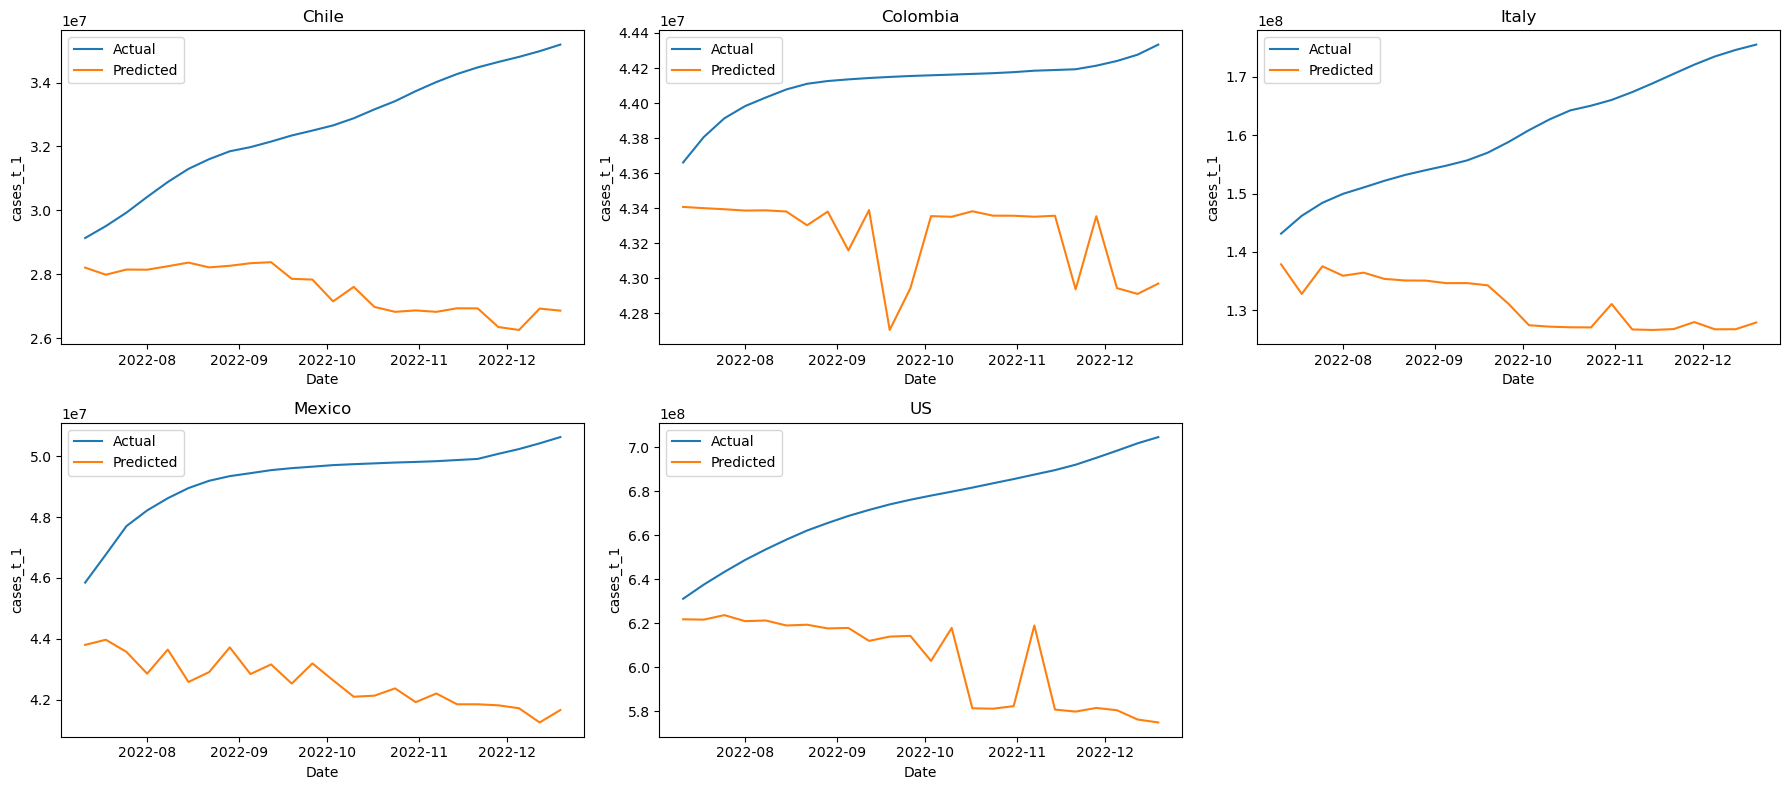

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])
df['week'] = df['date'].dt.isocalendar().week
df['month'] = df['date'].dt.month
df['dayofyear'] = df['date'].dt.dayofyear


# -------------------------------------------------------------
# 1.  Hyper‑parameter grid
# -------------------------------------------------------------
param_grid = {
    "n_estimators":     [200, 400, 600],
    "max_depth":        [None, 10, 20],
    "max_features":     ["sqrt", "log2", 0.6],
    "min_samples_split":[2, 5],
    "min_samples_leaf": [1, 2],
    "bootstrap":        [True, False],
}

results      = []   # metrics
plot_payload = []   # data for plotting

# -------------------------------------------------------------
# 2.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    df_c = df_c.sort_values('date').reset_index(drop=True)

    y = df_c['cases_t_1']
    X = df_c.drop(columns=['cases_t_1'])
    X_num = X.select_dtypes(include=np.number)          # predictors only

    # ---- 2.1  Outer split: take last fold as test
    outer_split = TimeSeriesSplit(n_splits=5)
    train_idx, test_idx = list(outer_split.split(X_num))[-1]

    X_train, X_test = X_num.iloc[train_idx], X_num.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']        # keep dates for plotting

    # ---- 2.2  Hyper‑parameter search on training portion
    inner_cv = TimeSeriesSplit(n_splits=3)
    rf_base  = RandomForestRegressor(random_state=42, n_jobs=-1)

    grid = GridSearchCV(
        estimator   = rf_base,
        param_grid  = param_grid,
        cv          = inner_cv,
        scoring     = "neg_root_mean_squared_error",
        n_jobs      = -1
    )
    grid.fit(X_train, y_train)
    best_rf = grid.best_estimator_

    # ---- 2.3  Evaluate on hold‑out
    y_pred = best_rf.predict(X_test)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2     = r2_score(y_test, y_pred)

    results.append({
        "country":     country,
        "rmse":        rmse,
        "r2":          r2,
        "best_params": grid.best_params_
    })

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred
    })

# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df[["country", "rmse", "r2"]])

# -------------------------------------------------------------
# 4.  2 × 3 subplot grid of actual vs. predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

# Hide any unused subplot (6‑th slot, since we have 5 countries)
for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()

(120, 23)
1815950.0 624861278.0 631046588.0 704518341.0


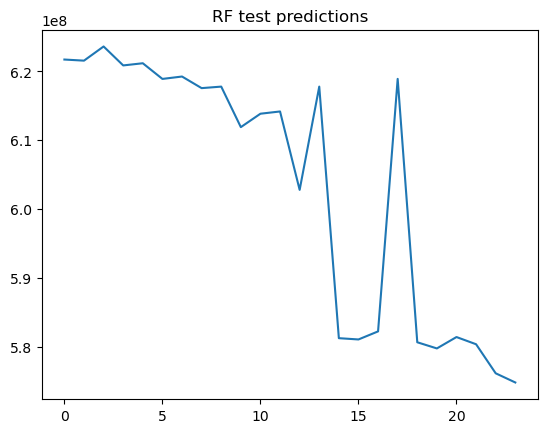

In [92]:
# 1. How many rows per country in the train fold?
print(X_train.shape)

# 2. Is the test target outside the training range?
print(y_train.min(), y_train.max(), y_test.min(), y_test.max())

# 3. Does RF simply predict a nearly flat line?
plt.plot(y_pred); plt.title("RF test predictions"); plt.show()

If you see a flat or clipped RF curve while the true series trends upward, it’s Reason #2. (Target drifts outside the range of the training data (trend, exponential growth/decay))

## Linear Regression

In [93]:
df = df_og.copy()

    country          rmse        r2
0     Chile  5.894265e+04  0.998847
1  Colombia  1.148394e+05  0.368373
2     Italy  3.237351e+05  0.998804
3    Mexico  1.871732e+05  0.971452
4        US  1.658932e+06  0.993050


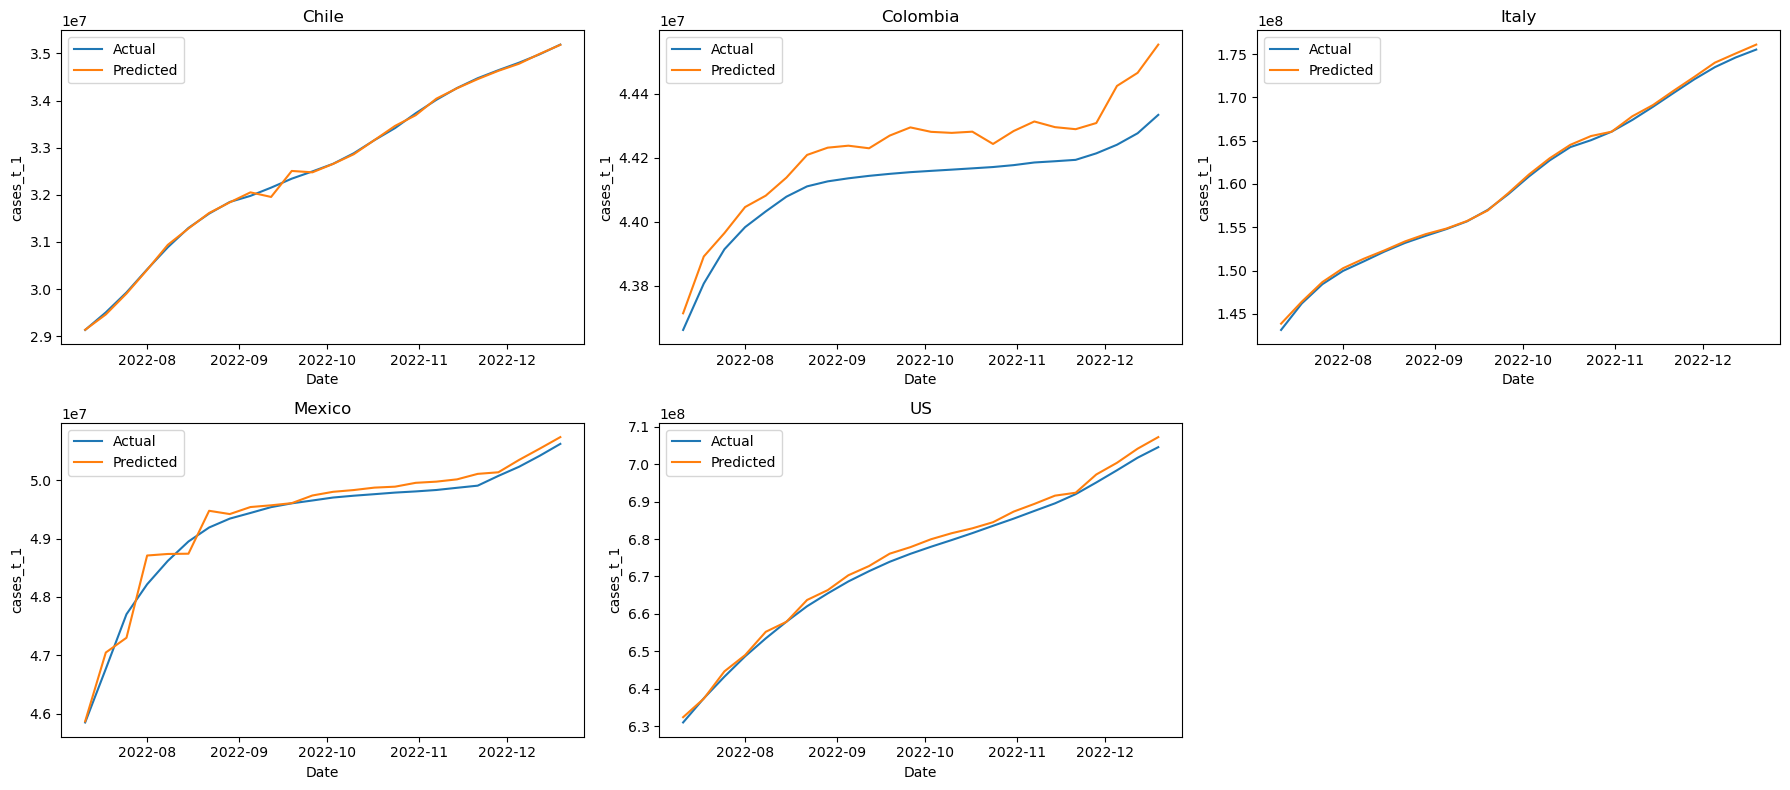

In [94]:
from sklearn.linear_model import LinearRegression


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])
#df['week'] = df['date'].dt.isocalendar().week
#df['month'] = df['date'].dt.month
#df['dayofyear'] = df['date'].dt.dayofyear

results      = []   # per‑country metrics
plot_payload = []   # dates, y_true, y_pred for plotting

# -------------------------------------------------------------
# 1.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 1.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 1.2  Split features / target
    y = df_c['cases_t_1']
    X = df_c.drop(columns=['cases_t_1', 'date' ])
    X = X.select_dtypes(include=np.number)            # numeric predictors only

    # ---- 1.3  Time‑series split: use last fold as test
    outer_split = TimeSeriesSplit(n_splits=5)
    train_idx, test_idx = list(outer_split.split(X))[-1]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 1.4  Fit Linear Regression (no tuning needed)
    linreg = LinearRegression()
    linreg.fit(X_train, y_train)

    # ---- 1.5  Predict + metrics
    y_pred = linreg.predict(X_test)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2     = r2_score(y_test, y_pred)

    results.append({
        "country": country,
        "rmse":    rmse,
        "r2":      r2
    })

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred
    })

# -------------------------------------------------------------
# 2.  Metrics DataFrame
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  2 × 3 subplot grid (last panel left blank)
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

# Hide unused subplot (panel 6)
for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


# Why?

Why does linear regression outperform RF:

| Symptom                                                                 | Why it hurts RF more than OLS                                                                 | How to check / fix                                                                 |
|-------------------------------------------------------------------------|---------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------|
| **Very small training set after the time-series split** (e.g. 200-400 rows per country) | Each tree sees only a bootstrap sample of an already tiny training set → high variance; Linear Regression has just p parameters and stays stable. | *Check:* `len(X_train)`. *Fix:* add more lags or switch to Gradient Boosting. |
| **Target drifts outside the training range** (trend, exponential growth/decay) | RF predictions are bounded by the min-max of the training targets, so it cannot extrapolate; a line can. | *Plot:* target vs. date—does the test period exceed historic highs? *Fix:* detrend (difference or log-transform) before fitting RF. |
| **Strong linear (or log-linear) relationship between predictors and target** | Linear Regression has the correct bias; RF wastes capacity learning a nearly linear mapping. | *Check:* scatter plots or a correlation heat-map. *Fix:* accept linear or enrich features (squares, interactions) so RF can exploit non-linearities. |
| **Too few trees / sub-optimal hyper-parameters** | With only 200-600 trees and tiny leaves, variance dominates. | *Fix:* use `n_estimators=2000`, `min_samples_leaf=5`, `max_depth=20`. |
| **Sparse or noisy predictors** | Linear Regression averages noise; trees may split on it, so ensemble variance remains high. | *Check:* feature std-dev and missingness. *Fix:* impute or smooth noisy inputs. |
| **Feature leakage in OLS but not RF** | If OLS keeps a future column (e.g. numeric timestamp), it "cheats"; RF may ignore it. | *Check:* are you feeding an ordinal timestamp? *Fix:* drop it or encode cyclically. |
| **Evaluation artefact (tuning leakage)** | Grid-searched RF peeks at earlier folds that share the same horizon; leakage helps OLS more. | *Fix:* nested CV or refit best params on fresh data. |

# XGBoost

In [95]:
df = df_og.copy()

    country          rmse         r2
0     Chile  4.411608e+06  -5.458023
1  Colombia  9.538506e+05 -42.575284
2     Italy  2.394049e+07  -5.541716
3    Mexico  6.477521e+06 -33.190057
4        US  5.272012e+07  -6.018679


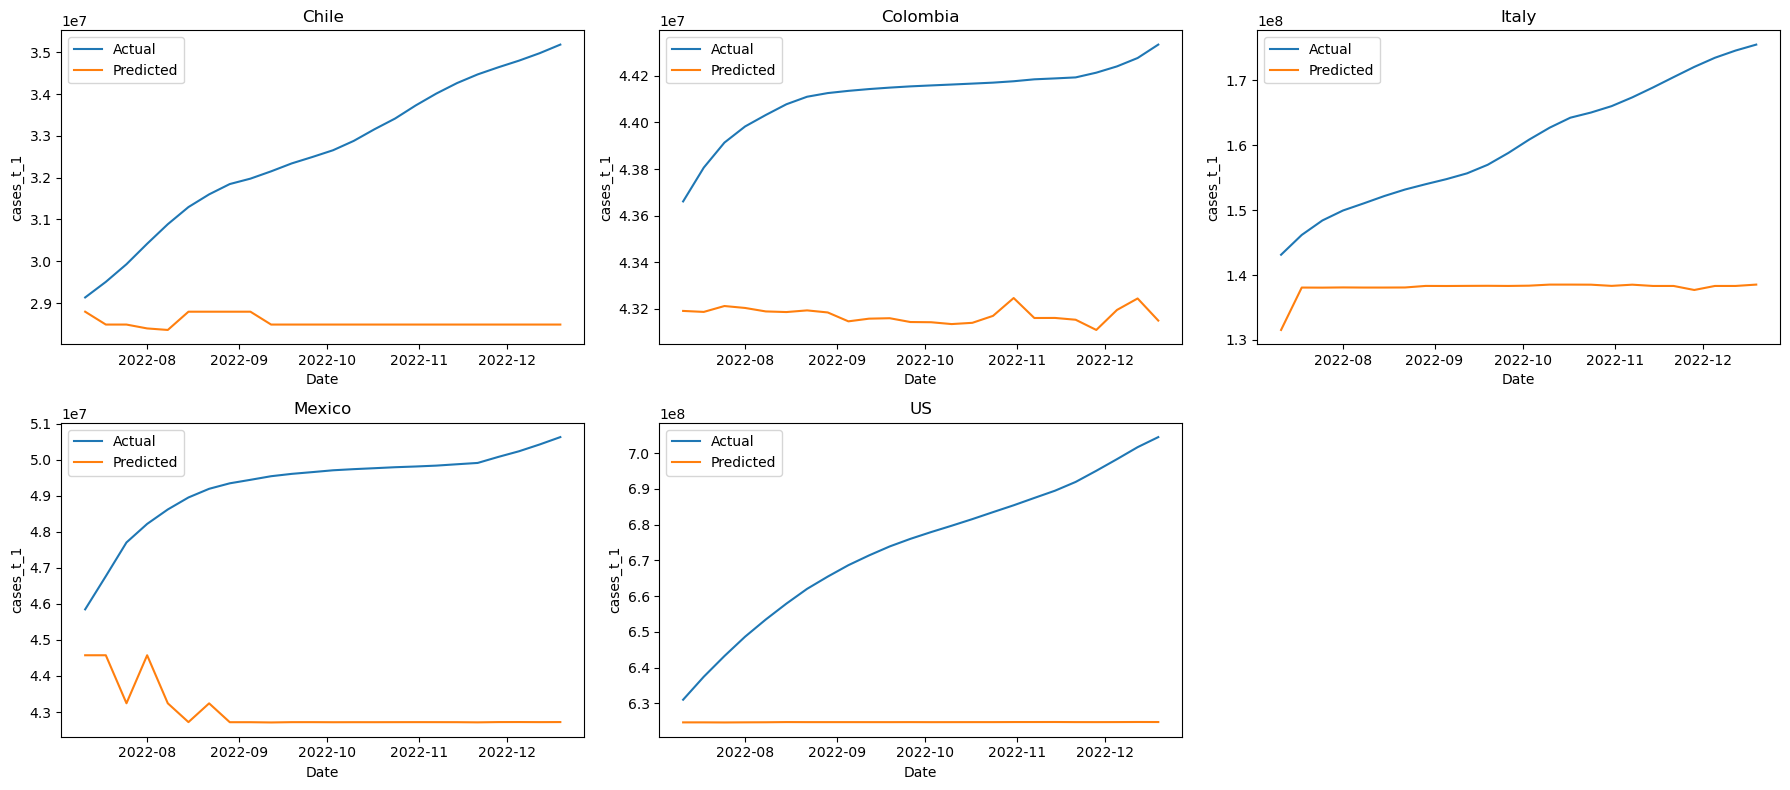

In [96]:

from xgboost               import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime and add simple calendar features
# -------------------------------------------------------------
df['date']      = pd.to_datetime(df['date'])
df['week']      = df['date'].dt.isocalendar().week.astype(int)
df['month']     = df['date'].dt.month
df['dayofyear'] = df['date'].dt.dayofyear

# -------------------------------------------------------------
# 1.  Hyper‑parameter grid for XGBRegressor
#    (coarse → zoom in later if needed)
# -------------------------------------------------------------
param_grid = {
    "n_estimators":      [200, 400, 600],
    "max_depth":         [3, 6, 10],
    "learning_rate":     [0.05, 0.1, 0.2],
    "subsample":         [0.8, 1.0],
    "colsample_bytree":  [0.6, 0.8, 1.0],
    "gamma":             [0, 1],
    "min_child_weight":  [1, 5],
}

results      = []   # metrics per country
plot_payload = []   # data for plotting

# -------------------------------------------------------------
# 2.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 2.1  Split features / target
    y = df_c['cases_t_1']
    X = df_c.drop(columns=['cases_t_1'])
    X = X.select_dtypes(include=np.number)    # numeric predictors only

    # ---- 2.2  Outer split: last fold is test
    outer_split = TimeSeriesSplit(n_splits=5)
    train_idx, test_idx = list(outer_split.split(X))[-1]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 2.3  Inner CV: grid‑search XGBoost on training portion
    inner_cv = TimeSeriesSplit(n_splits=3)

    xgb_base = XGBRegressor(
        objective    = "reg:squarederror",
        random_state = 42,
        n_jobs       = -1,
        tree_method  = "hist"          # much faster on CPU
    )

    grid = GridSearchCV(
        estimator   = xgb_base,
        param_grid  = param_grid,
        cv          = inner_cv,
        scoring     = "neg_root_mean_squared_error",
        n_jobs      = -1,
        verbose     = 0
    )
    grid.fit(X_train, y_train)
    best_xgb = grid.best_estimator_

    # ---- 2.4  Evaluate on unseen hold‑out
    y_pred = best_xgb.predict(X_test)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2     = r2_score(y_test, y_pred)

    results.append({
        "country":     country,
        "rmse":        rmse,
        "r2":          r2,
        "best_params": grid.best_params_
    })

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred
    })

# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df[["country", "rmse", "r2"]])

# -------------------------------------------------------------
# 4.  2 × 3 subplot grid of actual vs. predicted
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

# Hide the unused subplot (panel 6, since we have 5 countries)
for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()
